# Feature Correlation Analysis with PM2.5

Analysis of feature correlations across datasets to identify important predictors for PM2.5.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Load and Merge Datasets

In [10]:
openaq = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openaq_processed_20230601_to_20250630.csv')
openaq['timestamp'] = pd.to_datetime(openaq['timestamp'])
openaq['hour'] = openaq['timestamp'].dt.floor('H')

openmeteo = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv')
openmeteo['timestamp'] = pd.to_datetime(openmeteo['timestamp'], format='mixed')
openmeteo['hour'] = openmeteo['timestamp'].dt.floor('H')

jartic = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_jartic_processed_20230601_to_20250630_full.csv')
jartic['timestamp'] = pd.to_datetime(jartic['timestamp'])
jartic['hour'] = jartic['timestamp'].dt.floor('H')

print(f"Loaded OpenAQ: {openaq.shape}")
print(f"Loaded OpenMeteo: {openmeteo.shape}")
print(f"Loaded JARTIC: {jartic.shape}")

Loaded OpenAQ: (9579181, 27)
Loaded OpenMeteo: (547920, 42)
Loaded JARTIC: (18849324, 16)


In [11]:
openaq_hourly = openaq.groupby('hour').agg({
    'pm25_ugm3_mean': 'mean',
    'co_ppm_mean': 'mean', 
    'no2_ugm3_mean': 'mean',
    'so2_ugm3_mean': 'mean'
}).reset_index()
openaq_hourly = openaq_hourly.rename(columns={
    'pm25_ugm3_mean': 'pm25',
    'co_ppm_mean': 'co',
    'no2_ugm3_mean': 'no2', 
    'so2_ugm3_mean': 'so2'
})

openmeteo_hourly = openmeteo.groupby('hour').agg({
    'temperature_c_mean': 'mean',
    'humidity_pct_mean': 'mean',
    'precipitation_mm_mean': 'mean',
    'pressure_hpa_mean': 'mean',
    'cloud_cover_pct_mean': 'mean',
    'dew_point_c_mean': 'mean',
    'solar_radiation_wm2_mean': 'mean'
}).reset_index()
openmeteo_hourly = openmeteo_hourly.rename(columns={
    'temperature_c_mean': 'temperature',
    'humidity_pct_mean': 'humidity',
    'precipitation_mm_mean': 'precipitation',
    'pressure_hpa_mean': 'pressure',
    'cloud_cover_pct_mean': 'cloud_cover',
    'dew_point_c_mean': 'dew_point',
    'solar_radiation_wm2_mean': 'solar_radiation'
})

jartic_hourly = jartic.groupby('hour').agg({
    'avg_traffic_volume': 'mean',
    'avg_speed_kmh': 'mean',
    'congestion_index': 'mean'
}).reset_index()
jartic_hourly = jartic_hourly.rename(columns={
    'avg_traffic_volume': 'traffic_volume',
    'avg_speed_kmh': 'traffic_speed',
    'congestion_index': 'congestion'
})

merged = openaq_hourly.merge(openmeteo_hourly, on='hour', how='inner')
merged = merged.merge(jartic_hourly, on='hour', how='inner')

print(f"\nMerged dataset: {merged.shape}")
print(f"Date range: {merged['hour'].min()} to {merged['hour'].max()}")
print(f"Total hours with data: {len(merged)}")


Merged dataset: (15439, 15)
Date range: 2023-07-14 16:00:00+00:00 to 2025-06-30 12:00:00+00:00
Total hours with data: 15439


## Correlation Matrix

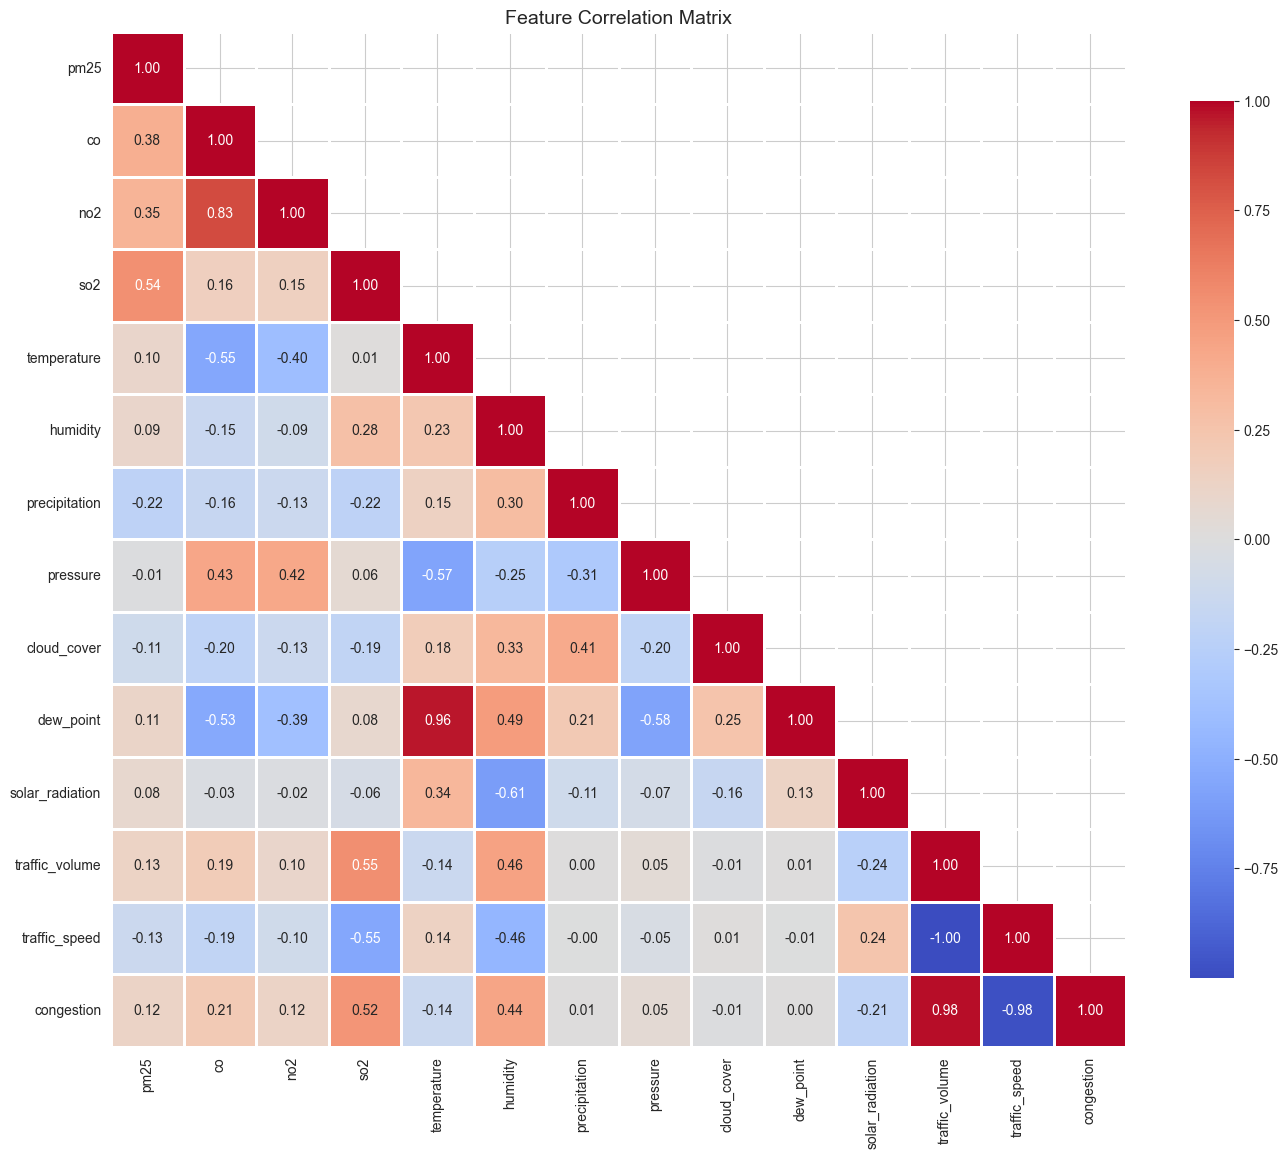

In [12]:
feature_cols = [col for col in merged.columns if col not in ['hour']]
correlation_matrix = merged[feature_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## PM2.5 Correlations

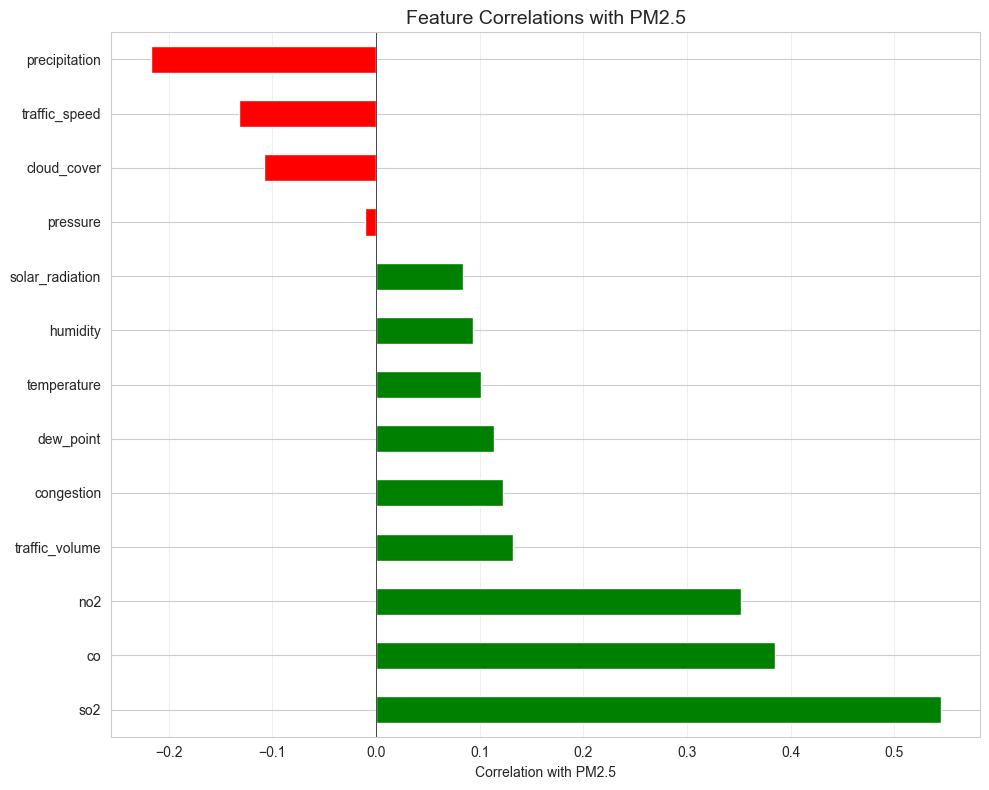

PM2.5 Correlations:
so2                 : +0.545
co                  : +0.385
no2                 : +0.352
traffic_volume      : +0.132
congestion          : +0.123
dew_point           : +0.114
temperature         : +0.101
humidity            : +0.094
solar_radiation     : +0.084
pressure            : -0.011
cloud_cover         : -0.108
traffic_speed       : -0.132
precipitation       : -0.217


In [13]:
pm25_correlations = correlation_matrix['pm25'].drop('pm25').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in pm25_correlations.values]
pm25_correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Correlation with PM2.5')
ax.set_title('Feature Correlations with PM2.5', fontsize=14)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("PM2.5 Correlations:")
print("="*40)
for feature, corr in pm25_correlations.items():
    print(f"{feature:20s}: {corr:+.3f}")

## Temporal Stability Analysis

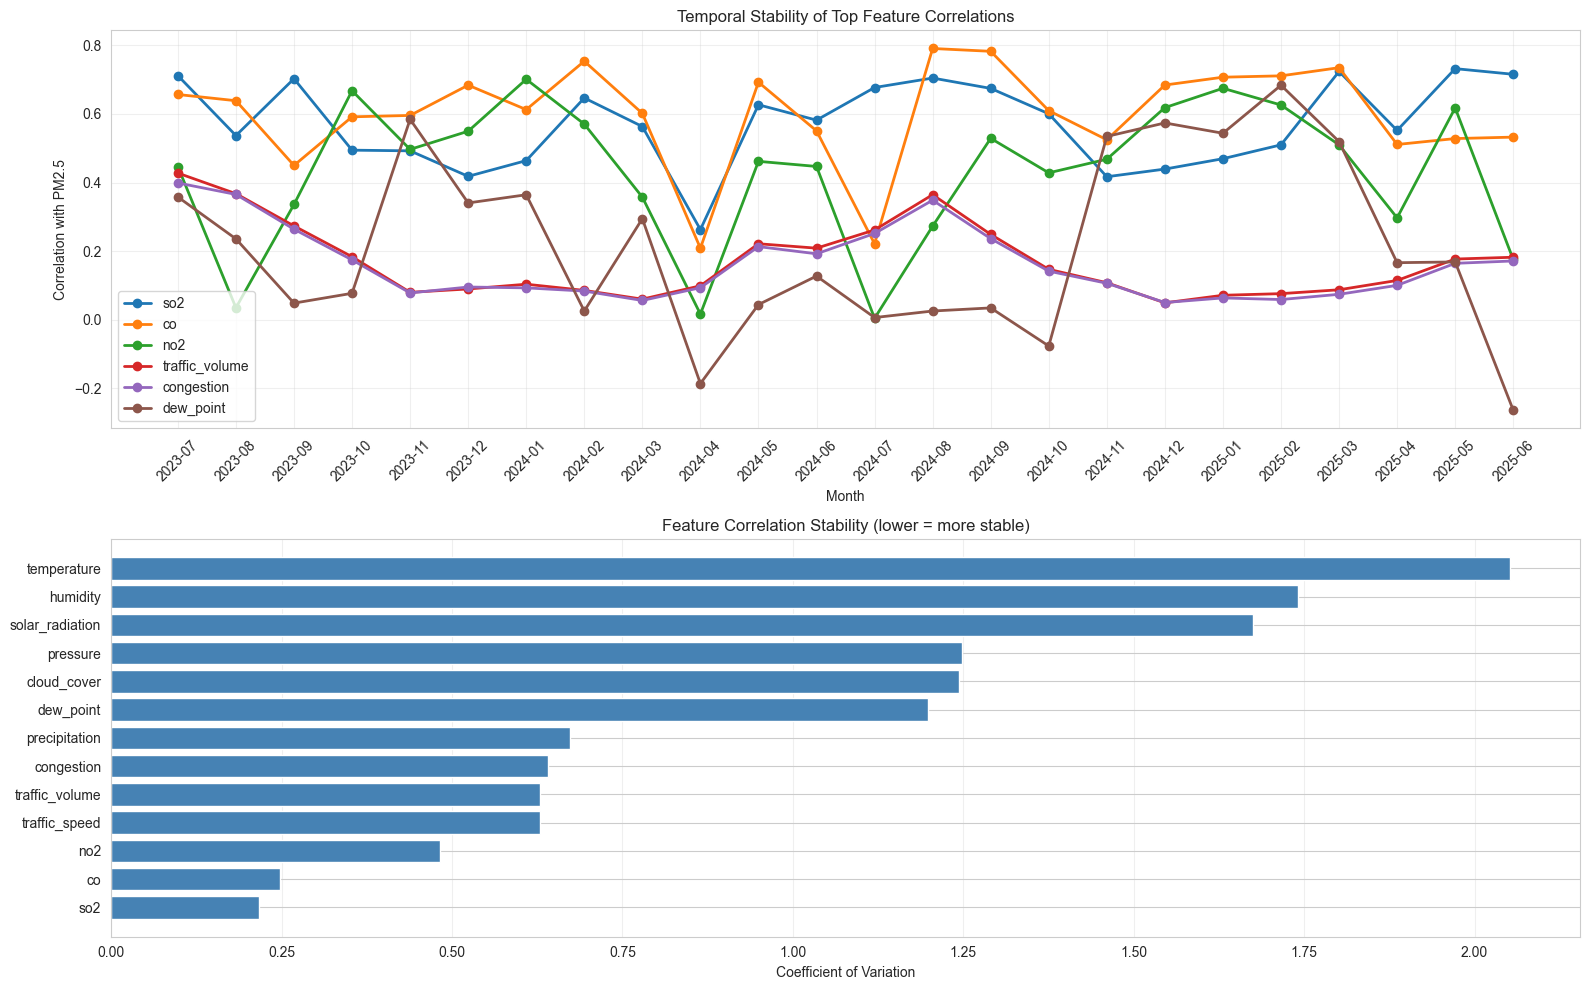

In [14]:
merged['year_month'] = merged['hour'].dt.to_period('M')
monthly_correlations = []

for month in merged['year_month'].unique():
    month_data = merged[merged['year_month'] == month]
    
    for feature in feature_cols:
        if feature != 'pm25':
            valid_data = month_data[['pm25', feature]].dropna()
            if len(valid_data) > 30:
                corr = valid_data['pm25'].corr(valid_data[feature])
                monthly_correlations.append({
                    'month': month,
                    'feature': feature,
                    'correlation': corr,
                    'samples': len(valid_data)
                })

if monthly_correlations:
    monthly_corr_df = pd.DataFrame(monthly_correlations)
    stability_pivot = monthly_corr_df.pivot(index='month', columns='feature', values='correlation')
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    top_features = pm25_correlations.abs().head(6).index
    for feature in top_features:
        if feature in stability_pivot.columns:
            axes[0].plot(stability_pivot.index.astype(str), stability_pivot[feature], 
                        marker='o', label=feature, linewidth=2)
    
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Correlation with PM2.5')
    axes[0].set_title('Temporal Stability of Top Feature Correlations', fontsize=12)
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    stability_std = stability_pivot.std()
    stability_mean = stability_pivot.mean()
    stability_cv = (stability_std / stability_mean.abs()).sort_values()
    
    axes[1].barh(range(len(stability_cv)), stability_cv.values, color='steelblue')
    axes[1].set_yticks(range(len(stability_cv)))
    axes[1].set_yticklabels(stability_cv.index)
    axes[1].set_xlabel('Coefficient of Variation')
    axes[1].set_title('Feature Correlation Stability (lower = more stable)', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("No monthly correlations available")
    stability_pivot = pd.DataFrame()
    stability_cv = pd.Series()

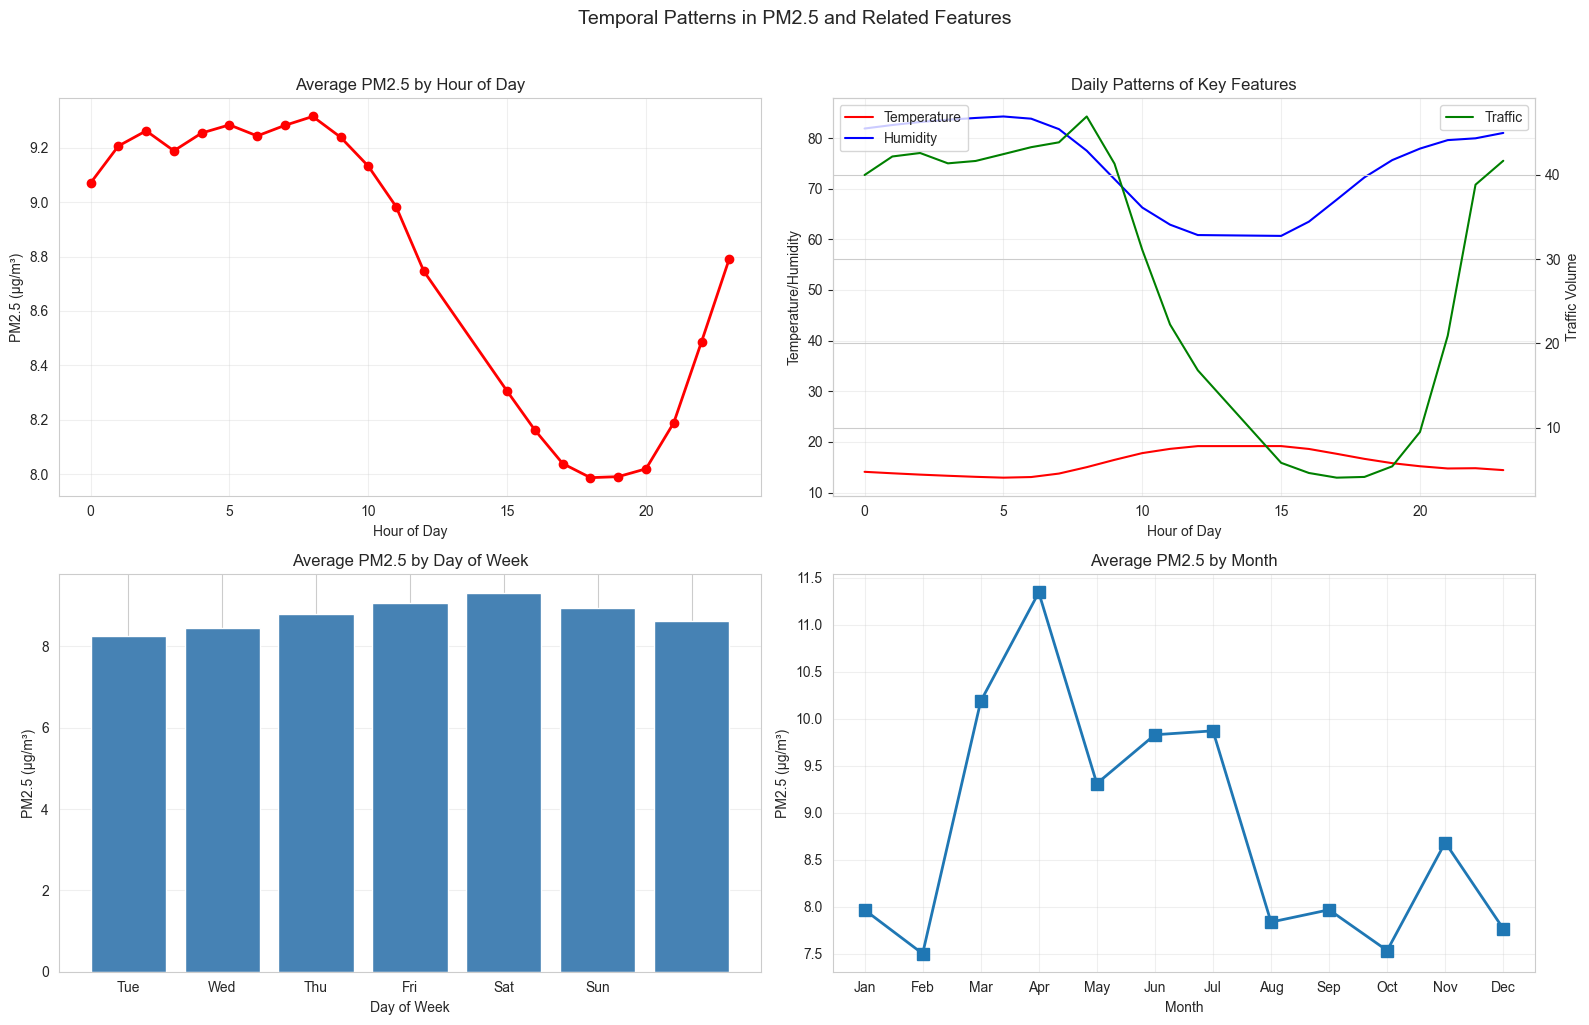

In [15]:
merged['hour_of_day'] = merged['hour'].dt.hour
merged['day_of_week'] = merged['hour'].dt.dayofweek
merged['month_num'] = merged['hour'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hourly_pm25 = merged.groupby('hour_of_day')['pm25'].mean()
axes[0, 0].plot(hourly_pm25.index, hourly_pm25.values, marker='o', linewidth=2, color='red')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_title('Average PM2.5 by Hour of Day')
axes[0, 0].grid(True, alpha=0.3)

daily_features = merged.groupby('hour_of_day')[['temperature', 'humidity', 'traffic_volume']].mean()
ax2 = axes[0, 1].twinx()
axes[0, 1].plot(daily_features.index, daily_features['temperature'], 'r-', label='Temperature')
axes[0, 1].plot(daily_features.index, daily_features['humidity'], 'b-', label='Humidity')
ax2.plot(daily_features.index, daily_features['traffic_volume'], 'g-', label='Traffic')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Temperature/Humidity')
ax2.set_ylabel('Traffic Volume')
axes[0, 1].set_title('Daily Patterns of Key Features')
axes[0, 1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

dow_pm25 = merged.groupby('day_of_week')['pm25'].mean()
axes[1, 0].bar(dow_pm25.index, dow_pm25.values, color='steelblue')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('PM2.5 (μg/m³)')
axes[1, 0].set_title('Average PM2.5 by Day of Week')
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].grid(True, alpha=0.3, axis='y')

monthly_pm25 = merged.groupby('month_num')['pm25'].mean()
axes[1, 1].plot(monthly_pm25.index, monthly_pm25.values, marker='s', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
axes[1, 1].set_title('Average PM2.5 by Month')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Temporal Patterns in PM2.5 and Related Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Daily Pattern Analysis

## Feature Importance Summary

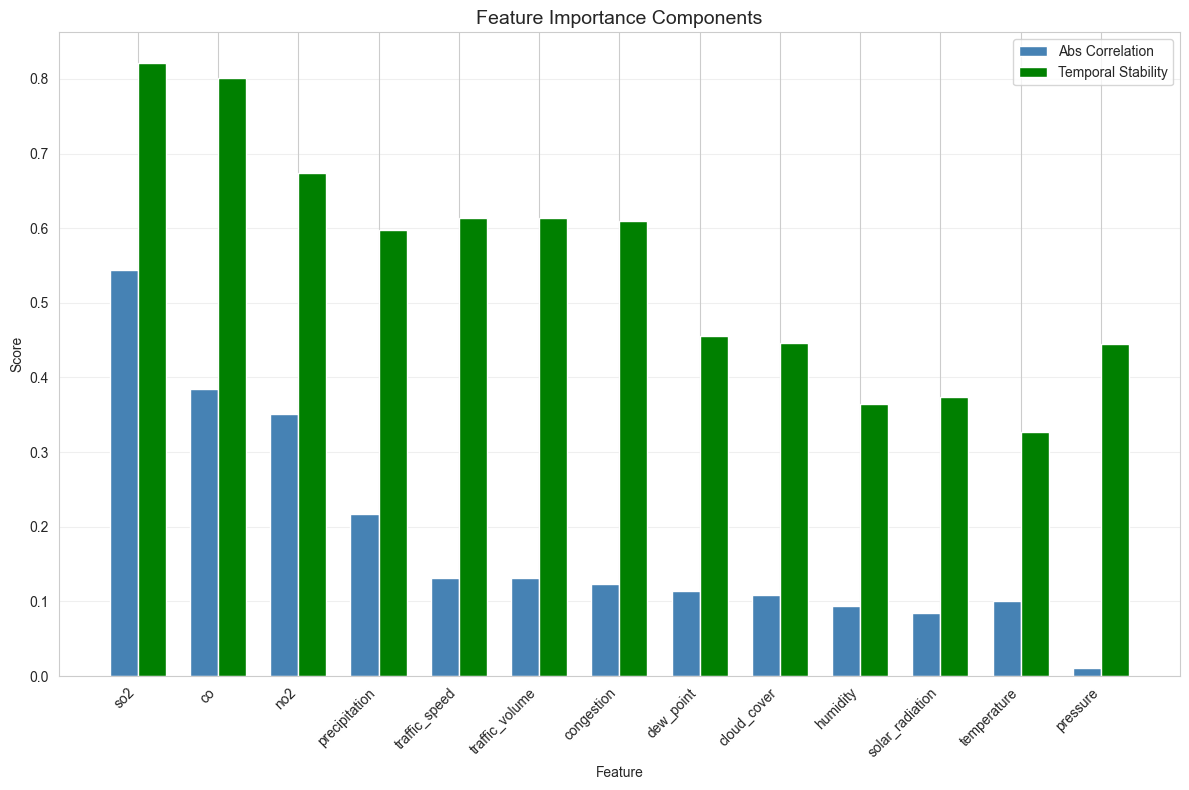

Feature Importance Ranking:


,Feature,Correlation,Abs_Correlation,Temporal_Stability,Overall_Score
0,so2,0.545,0.545,0.821,0.628
1,co,0.385,0.385,0.801,0.510
2,no2,0.352,0.352,0.675,0.449
12,precipitation,-0.217,0.217,0.598,0.332
11,traffic_speed,-0.132,0.132,0.614,0.276
3,traffic_volume,0.132,0.132,0.614,0.276
4,congestion,0.123,0.123,0.609,0.269
5,dew_point,0.114,0.114,0.455,0.216
10,cloud_cover,-0.108,0.108,0.446,0.210
7,humidity,0.094,0.094,0.365,0.175


: 

In [ ]:
if len(pm25_correlations) > 0:
    feature_importance = pd.DataFrame({
        'Feature': pm25_correlations.index,
        'Correlation': pm25_correlations.values,
        'Abs_Correlation': pm25_correlations.abs().values
    })
    
    if len(stability_cv) > 0:
        feature_importance['Temporal_Stability'] = feature_importance['Feature'].apply(
            lambda x: 1 / (1 + stability_cv.get(x, 1)) if x in stability_cv.index else 0.5
        )
    else:
        feature_importance['Temporal_Stability'] = 0.5
    
    feature_importance['Overall_Score'] = (
        feature_importance['Abs_Correlation'] * 0.7 +
        feature_importance['Temporal_Stability'] * 0.3
    )
    
    feature_importance = feature_importance.sort_values('Overall_Score', ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(feature_importance))
    width = 0.35
    
    ax.bar(x - width/2, feature_importance['Abs_Correlation'], width, label='Abs Correlation', color='steelblue')
    ax.bar(x + width/2, feature_importance['Temporal_Stability'], width, label='Temporal Stability', color='green')
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Score')
    ax.set_title('Feature Importance Components', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_importance['Feature'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("Feature Importance Ranking:")
    print("="*60)
    display(feature_importance)
else:
    print("No feature correlations available")